# Por: Nicolas Bernal M.

# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [104]:
import pandas as pd


df = pd.read_csv(
    "athlete_events.csv",
    na_values= ['NA']
    )

df['Medal'] = df['Medal'].fillna("No medal")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 206152 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      206152 non-null  int64  
 1   Name    206152 non-null  object 
 2   Sex     206152 non-null  object 
 3   Age     206152 non-null  float64
 4   Height  206152 non-null  float64
 5   Weight  206152 non-null  float64
 6   Team    206152 non-null  object 
 7   NOC     206152 non-null  object 
 8   Games   206152 non-null  object 
 9   Year    206152 non-null  int64  
 10  Season  206152 non-null  object 
 11  City    206152 non-null  object 
 12  Sport   206152 non-null  object 
 13  Event   206152 non-null  object 
 14  Medal   206152 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 25.2+ MB


In [105]:
df.drop(["ID", "Games", "NOC", "Name", "Event"], inplace=True, axis=1)

df.describe()

,Age,Height,Weight,Year
count,206152.000000,206152.000000,206152.000000,206152.00000
mean,25.054736,175.372056,70.688332,1989.67849
std,5.481679,10.545816,14.340633,20.12571
min,11.000000,127.000000,25.000000,1896.00000
25%,21.000000,168.000000,60.000000,1976.00000
50%,24.000000,175.000000,70.000000,1992.00000
75%,28.000000,183.000000,79.000000,2006.00000
max,71.000000,226.000000,214.000000,2016.00000


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [106]:
df.describe(include="object").T

,count,unique,top,freq
Sex,206152,2,M,139441
Team,206152,660,United States,13707
Season,206152,2,Summer,166693
City,206152,42,London,13803
Sport,206152,56,Athletics,32374
Medal,206152,4,No medal,175971


In [107]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable Sex es: 
 Sex
M    139441
F     66711
Name: count, dtype: int64 

El conteo de la variable Team es: 
 Team
United States       13707
France               7805
Canada               7668
Great Britain        7498
Italy                7433
                    ...  
Greenoaks Dundee        1
Sunrise                 1
Dow Jones               1
Mexico-2                1
Digby                   1
Name: count, Length: 660, dtype: int64 

El conteo de la variable Season es: 
 Season
Summer    166693
Winter     39459
Name: count, dtype: int64 

El conteo de la variable City es: 
 City
London                    13803
Sydney                    13682
Athina                    13640
Rio de Janeiro            13443
Beijing                   13402
Atlanta                   11838
Seoul                     11618
Barcelona                 10326
Munich                     9847
Los Angeles                9356
Mexico City                8402
Montreal                   8265
Roma     

Variables nominales: Sex, Team, Season, City, Sport, Event.

Variables ordinales: Medal.

Las variables con mayor cardinalidad es Team, pero no la llamaria de alta cardinalidad al ser un maximo de 660 valoes unicos de mas de 200.000 registros (0.3%).

Solo Team presenta categorias atipicas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

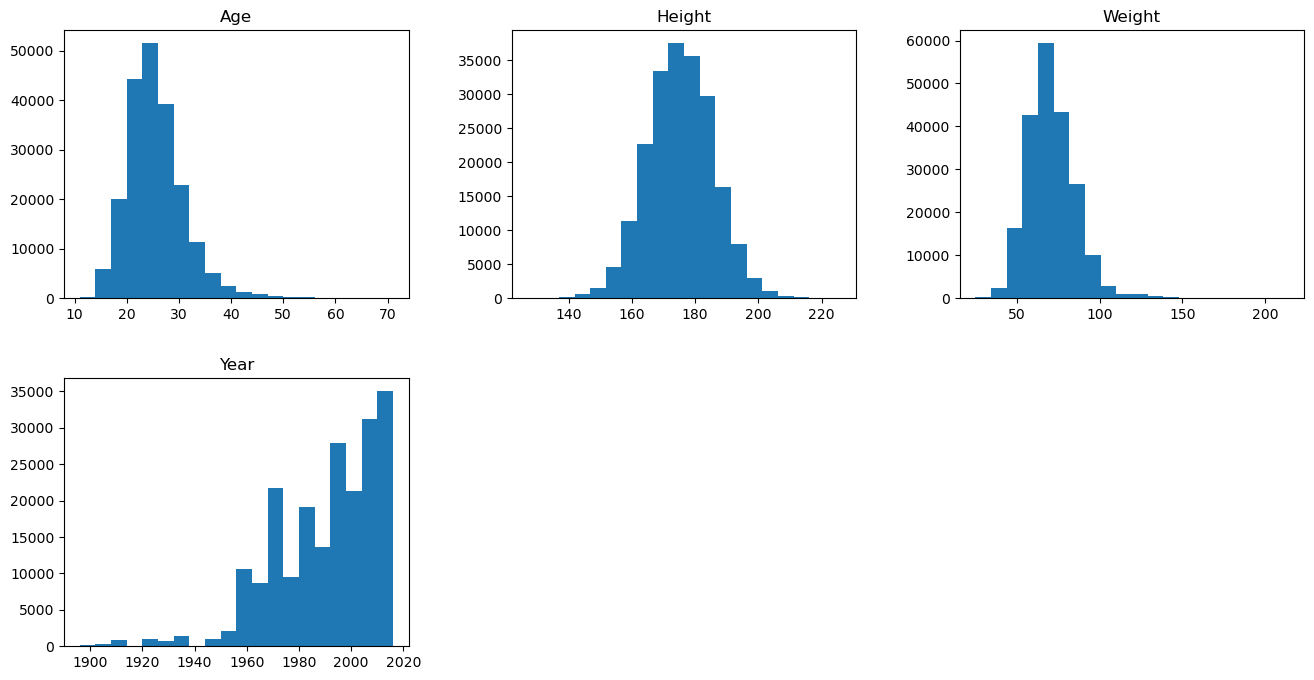

In [108]:
df.hist(figsize=(16, 8), bins=20, layout=(2,3), grid=False, sharex=False, sharey=False);

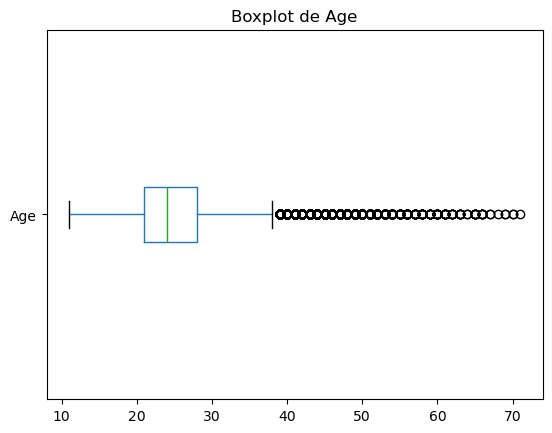

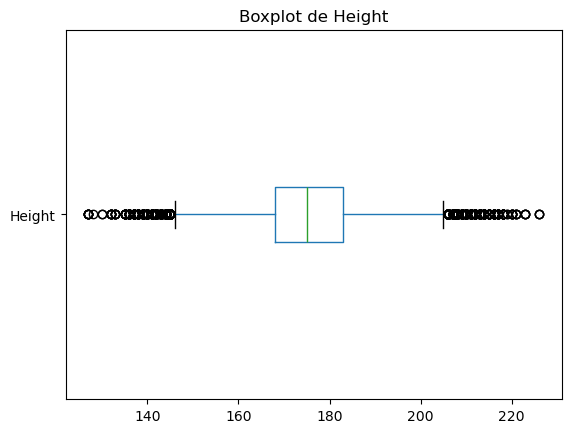

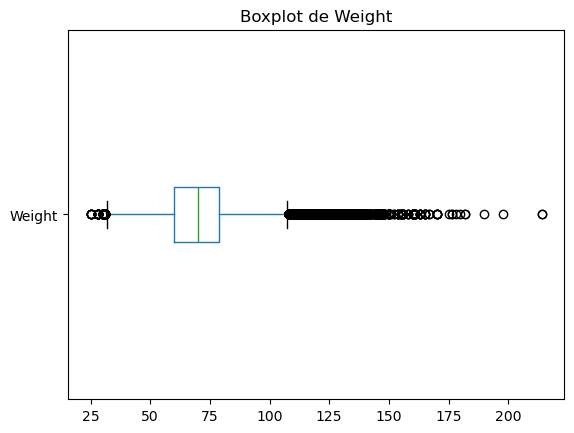

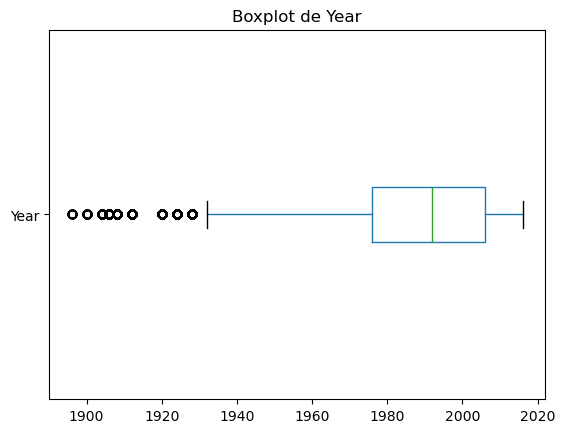

In [109]:
import matplotlib.pyplot as plt

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

Segun los histogramas podemos ver que Age, Height y Weight son aproximadamente normales, siendo Height la mas aparentemente normal mientras que Age y Weight tienen sus valores con tendencia hacia la izquierda.

Todas las variables numericas presentan outliers, siendo Weight y Height los que presentan mas.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

<Axes: >

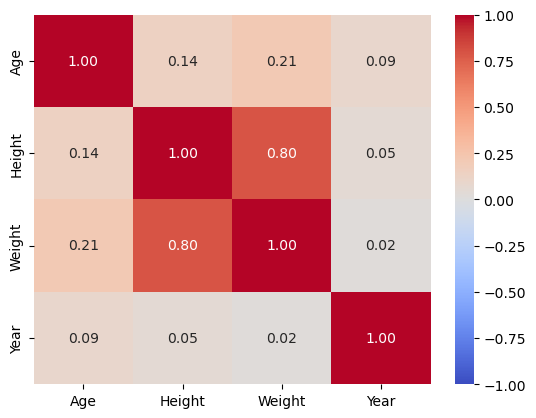

In [110]:
import seaborn as sns

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

<Figure size 640x480 with 0 Axes>

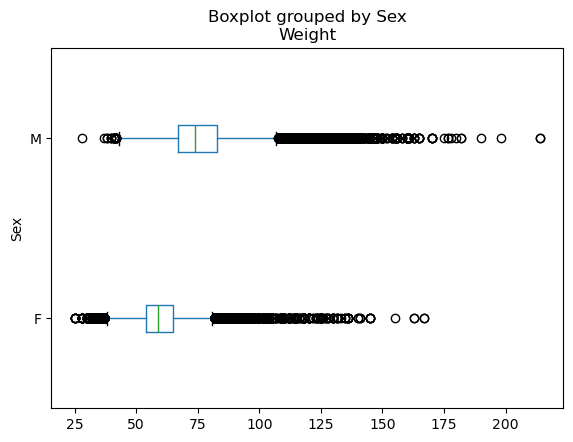

<Figure size 640x480 with 0 Axes>

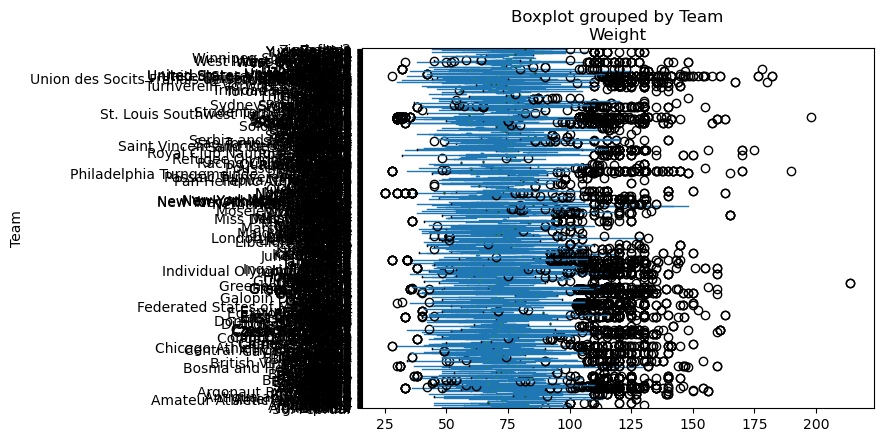

<Figure size 640x480 with 0 Axes>

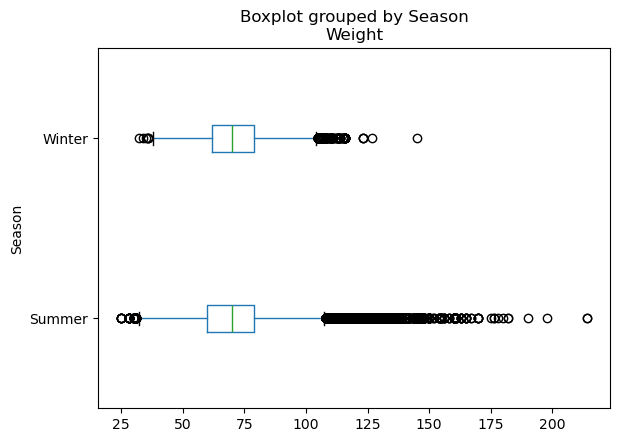

<Figure size 640x480 with 0 Axes>

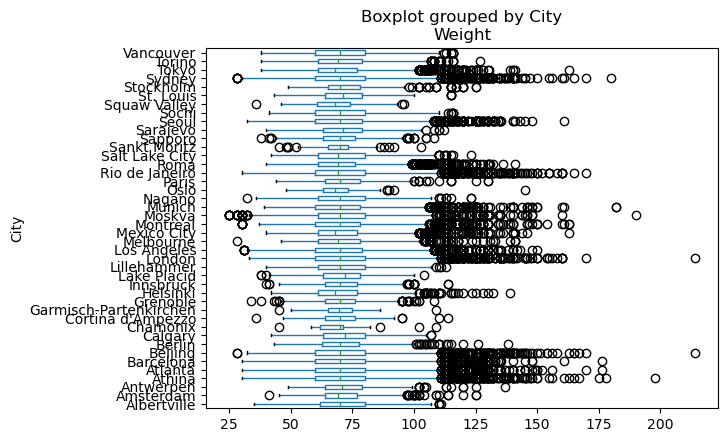

<Figure size 640x480 with 0 Axes>

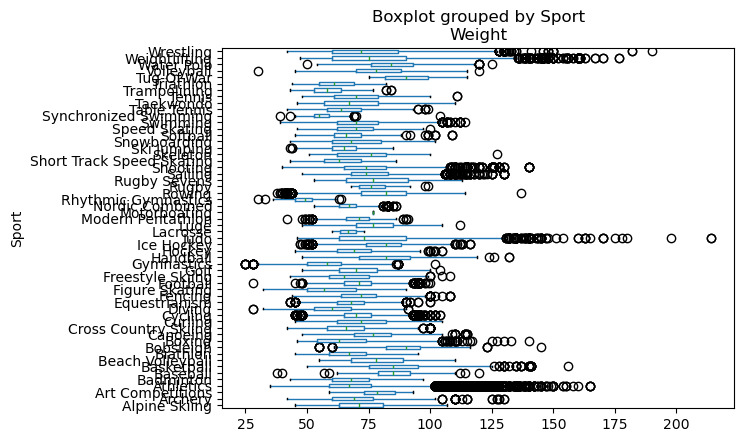

<Figure size 640x480 with 0 Axes>

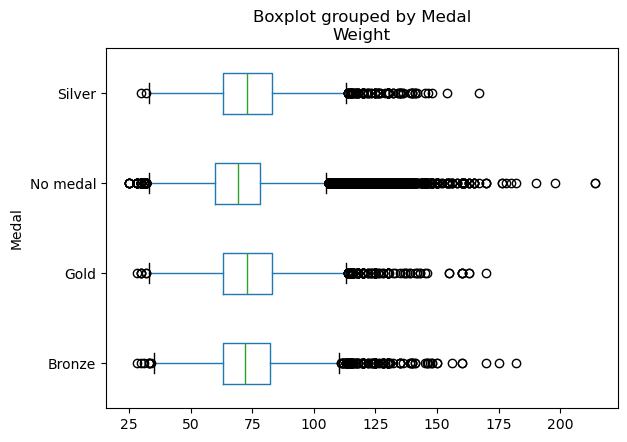

In [111]:
for var in cat_vars:
    plt.figure()
    df.boxplot(column="Weight", by=var, grid=False, vert=False)
    plt.show()

Para las variables numericas se observa que Height es la variable con mayor correlacion, por lo que se asume que puede ser buena predictora.

Para las variables categoricas se observa que Sex y Sport son las que en apariencia pueden ser buenas predictoras.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [112]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ['Weight'],
    axis=1
    )

y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (164921, 9)
Tamaño del conjunto de prueba es: (41231, 9)


Las caracteristicas que elegi para procesar son: Medal, Sex, Sport, Height y Age

In [113]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

ss = StandardScaler() # Para preprocesar Height y Age
orden = ["No medal", "Bronze", "Silver", "Gold"]
ore = OrdinalEncoder(categories=[orden], dtype='int') # Para preprocesar Medal
ohe = OneHotEncoder(sparse_output=False, drop='if_binary', max_categories=20) # para preprocesar Sex y Sport (Sport limitado a 15 categorias)


preprocessor = ColumnTransformer(transformers=[
    ('height_age', ss, ['Height', 'Age']),
    ('medal', ore, ['Medal']),
    ('sex_sport', ohe, ["Sex", "Sport"])
    ],
    remainder='drop') 

preprocessor

ColumnTransformer(transformers=[('height_age', StandardScaler(),
                                 ['Height', 'Age']),
                                ('medal',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']],
                                                dtype='int'),
                                 ['Medal']),
                                ('sex_sport',
                                 OneHotEncoder(drop='if_binary',
                                               max_categories=20,
                                               sparse_output=False),
                                 ['Sex', 'Sport'])])

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
    ])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('height_age',
                                                  StandardScaler(),
                                                  ['Height', 'Age']),
                                                 ('medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal']),
                                                 ('sex_sport',
                                                  OneHotEncoder(drop='if_binary',
                                                                max_categories=20,
                                                                sparse_output=False),
                                                  ['Sex', 'Sport'])])),
                ('model', Ridge())])

In [115]:
df_sex_sport = df[["Sex", "Sport"]]

sex_sport_cod = ohe.fit_transform(df_sex_sport)

df_sex_sport_cod = pd.DataFrame(
    data=sex_sport_cod,
    columns=ohe.get_feature_names_out(),
    index=df.index
    )

print(df_sex_sport_cod.columns)

Index(['Sex_M', 'Sport_Alpine Skiing', 'Sport_Athletics', 'Sport_Biathlon',
       'Sport_Boxing', 'Sport_Canoeing', 'Sport_Cross Country Skiing',
       'Sport_Cycling', 'Sport_Equestrianism', 'Sport_Fencing',
       'Sport_Football', 'Sport_Gymnastics', 'Sport_Hockey',
       'Sport_Ice Hockey', 'Sport_Rowing', 'Sport_Sailing', 'Sport_Shooting',
       'Sport_Speed Skating', 'Sport_Swimming', 'Sport_Wrestling',
       'Sport_infrequent_sklearn'],
      dtype='object')


In [116]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('height_age',
                                                  StandardScaler(),
                                                  ['Height', 'Age']),
                                                 ('medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal']),
                                                 ('sex_sport',
                                                  OneHotEncoder(drop='if_binary',
                                                                max_categories=20,
                                                                sparse_output=False),
                                                  ['Sex', 'Sport'])])),
                ('model', Ridge())])

In [117]:
print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.6903067647413739
Exactitud del modelo en el conjunto de prueba: 0.693521209373734


El modelo fue entrenado con las siguientes categorias reales:

Height, Age, Medal, 'Sex_M', 'Sport_Alpine Skiing', 'Sport_Athletics', 'Sport_Biathlon',
       'Sport_Boxing', 'Sport_Canoeing', 'Sport_Cross Country Skiing',
       'Sport_Cycling', 'Sport_Equestrianism', 'Sport_Fencing',
       'Sport_Football', 'Sport_Gymnastics', 'Sport_Hockey',
       'Sport_Ice Hockey', 'Sport_Rowing', 'Sport_Sailing', 'Sport_Shooting',
       'Sport_Speed Skating', 'Sport_Swimming', 'Sport_Wrestling',
       'Sport_infrequent_sklearn'

Los scores de procesamiento y prueba son 69.03% y 68.35% respectivamente.

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

Se hara el re-entreno con las caracteristicas: Medal, Sex, Sport, Height, Age, Season y Year. Siendo Season y Year las caracteristicas adicionales 

In [118]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer

ss = StandardScaler() # Para preprocesar Height y Age
orden = ["No medal", "Bronze", "Silver", "Gold"]
pt = PowerTransformer() #Para procesar Year
ore = OrdinalEncoder(categories=[orden], dtype='int') # Para preprocesar Medal
ohe = OneHotEncoder(sparse_output=False, drop='if_binary', max_categories=20) # para preprocesar Sex, Sport (Sport limitado a 15 categorias) y Season


preprocessor = ColumnTransformer(transformers=[
    ('height_age', ss, ['Height', 'Age']),
    ('year', pt, ["Year"]),
    ('medal', ore, ['Medal']),
    ('sex_sport_season', ohe, ["Sex", "Sport", "Season"])
    ],
    remainder='drop') 

preprocessor

ColumnTransformer(transformers=[('height_age', StandardScaler(),
                                 ['Height', 'Age']),
                                ('year', PowerTransformer(), ['Year']),
                                ('medal',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']],
                                                dtype='int'),
                                 ['Medal']),
                                ('sex_sport_season',
                                 OneHotEncoder(drop='if_binary',
                                               max_categories=20,
                                               sparse_output=False),
                                 ['Sex', 'Sport', 'Season'])])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
    ])

pipeline.fit(X_train, y_train)

print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Exactitud del modelo en el conjunto de entrenamiento: 0.6907186765733424
Exactitud del modelo en el conjunto de prueba: 0.6936699589729087


<bound method Pipeline.get_feature_names_out of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('height_age',
                                                  StandardScaler(),
                                                  ['Height', 'Age']),
                                                 ('year', PowerTransformer(),
                                                  ['Year']),
                                                 ('medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
     

In [121]:
df_sex_sport = df[["Sex", "Sport", "Season"]]

sex_sport_cod = ohe.fit_transform(df_sex_sport)

df_sex_sport_cod = pd.DataFrame(
    data=sex_sport_cod,
    columns=ohe.get_feature_names_out(),
    index=df.index
    )

print(df_sex_sport_cod.columns)

Index(['Sex_M', 'Sport_Alpine Skiing', 'Sport_Athletics', 'Sport_Biathlon',
       'Sport_Boxing', 'Sport_Canoeing', 'Sport_Cross Country Skiing',
       'Sport_Cycling', 'Sport_Equestrianism', 'Sport_Fencing',
       'Sport_Football', 'Sport_Gymnastics', 'Sport_Hockey',
       'Sport_Ice Hockey', 'Sport_Rowing', 'Sport_Sailing', 'Sport_Shooting',
       'Sport_Speed Skating', 'Sport_Swimming', 'Sport_Wrestling',
       'Sport_infrequent_sklearn', 'Season_Winter'],
      dtype='object')


El modelo fue re-entrenado con las siguientes categorias reales:

Height, Age, Medal, Year, 'Sex_M', 'Sport_Alpine Skiing', 'Sport_Athletics', 'Sport_Biathlon',
       'Sport_Boxing', 'Sport_Canoeing', 'Sport_Cross Country Skiing',
       'Sport_Cycling', 'Sport_Equestrianism', 'Sport_Fencing',
       'Sport_Football', 'Sport_Gymnastics', 'Sport_Hockey',
       'Sport_Ice Hockey', 'Sport_Rowing', 'Sport_Sailing', 'Sport_Shooting',
       'Sport_Speed Skating', 'Sport_Swimming', 'Sport_Wrestling',
       'Sport_infrequent_sklearn', 'Season_Winter'

Los scores de procesamiento y prueba son 69.% y 68.36% respectivamente.